## PubMedBert(Axis 1) + MLP(Axis 2)

In [1]:
!pip install python-dotenv

In [2]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from pubmed_loader import PubMedQAData
from pubmedbert_preprocess import pubmedbert_preprocess

from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, training_curves

In [3]:
RANDOM_SEED = 11
MODEL_NAME  = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
DEVICE      = torch.device("xpu" if torch.xpu.is_available() else
               "cuda" if torch.cuda.is_available() else "cpu")

LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

set_all_seeds()
print(f"Using device: {DEVICE}")

All seeds set to 11
Using device: cpu


### 1. Data loading

In [4]:
data = PubMedQAData("data")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Variant A — plain question + context
train_enc_a, train_labels = pubmedbert_preprocess(data.train_set, tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)
dev_enc_a,   dev_labels   = pubmedbert_preprocess(data.dev_set,   tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)
test_enc_a,  test_labels  = pubmedbert_preprocess(data.test_set,  tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME), use_mesh=False)

# Variant B — question + context + MeSH terms appended
tokenizer_b = AutoTokenizer.from_pretrained(MODEL_NAME)
train_enc_b, _            = pubmedbert_preprocess(data.train_set, tokenizer=tokenizer_b, use_mesh=True)
dev_enc_b,   _            = pubmedbert_preprocess(data.dev_set,   tokenizer=tokenizer_b, use_mesh=True)
test_enc_b,  _            = pubmedbert_preprocess(data.test_set,  tokenizer=tokenizer_b, use_mesh=True)

print(f"train: {len(train_labels)} | dev: {len(dev_labels)} | test: {len(test_labels)}")
print("Train label dist:", np.bincount(train_labels.numpy()))
print("Dev   label dist:", np.bincount(dev_labels.numpy()))
print("Test  label dist:", np.bincount(test_labels.numpy()))

train: 450 | dev: 50 | test: 500
Train label dist: [249 152  49]
Dev   label dist: [27 17  6]
Test  label dist: [276 169  55]


### 2. Class Weights


In [5]:
counts        = np.bincount(train_labels.numpy())
counts_tensor = torch.FloatTensor(counts)
class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * 3   # normalise to n_classes

print(f"Class counts : {counts}  (yes / no / maybe)")
print(f"Class weights: {class_weights.numpy().round(4)}")

Class counts : [249 152  49]  (yes / no / maybe)
Class weights: [0.3886 0.6366 1.9748]


### 3. Pre-compute BERT Embeddings
Because BERT is fully frozen, we run it **once** over every split and cache the `[CLS]` vectors.
All MLP training then operates on plain `(N, 768)` float tensors — no BERT forward pass per epoch.

In [34]:
def extract_cls_embeddings(encodings, model, device, batch_size=32):
    """
    Run frozen BERT once and return (N, 768) [CLS] embeddings.
    """
    model.eval()
    all_cls = []
    n = encodings["input_ids"].size(0)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end       = min(start + batch_size, n)
            input_ids = encodings["input_ids"][start:end].to(device)
            attn_mask = encodings["attention_mask"][start:end].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask)
            cls_vec   = outputs.last_hidden_state[:, 0, :].cpu()
            all_cls.append(cls_vec)

    return torch.cat(all_cls, dim=0)   # (N, 768)


bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
for name, p in bert_model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name or "pooler" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False
print("BERT loaded and frozen.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded and frozen.


---
### Axis 1 — Text Representation

| | Input to BERT |
|---|---|
| **Variant A** | `[question] + [context]` (plain baseline) |
| **Variant B** | `[question] + [context] + MeSH terms` (enriched) |

**Hypothesis:** MeSH terms are controlled biomedical vocabulary.  By adding them, the `[CLS]` embedding for domain-specific topics may be improved, particularly for the minority `maybe` class. However, MeSH terms appear at the end of the 512-token window so if a context is already long they may get truncated. This is a crucial failure scenario to look for in error analysis.

In [35]:
# ── Variant A ──────────────────────────────────────────────────────────────
print("Extracting Variant A embeddings (plain)...")
train_emb_a = extract_cls_embeddings(train_enc_a, bert_model, DEVICE)
dev_emb_a   = extract_cls_embeddings(dev_enc_a,   bert_model, DEVICE)
test_emb_a  = extract_cls_embeddings(test_enc_a,  bert_model, DEVICE)
print(f"  train {train_emb_a.shape} | dev {dev_emb_a.shape} | test {test_emb_a.shape}")

# ── Variant B ──────────────────────────────────────────────────────────────
print("Extracting Variant B embeddings (+ MeSH)...")
train_emb_b = extract_cls_embeddings(train_enc_b, bert_model, DEVICE)
dev_emb_b   = extract_cls_embeddings(dev_enc_b,   bert_model, DEVICE)
test_emb_b  = extract_cls_embeddings(test_enc_b,  bert_model, DEVICE)
print(f"  train {train_emb_b.shape} | dev {dev_emb_b.shape} | test {test_emb_b.shape}")

print("\nDone. BERT will not run again during MLP training.")

Extracting Variant A embeddings (plain)...
  train torch.Size([450, 768]) | dev torch.Size([50, 768]) | test torch.Size([500, 768])
Extracting Variant B embeddings (+ MeSH)...
  train torch.Size([450, 768]) | dev torch.Size([50, 768]) | test torch.Size([500, 768])

Done. BERT will not run again during MLP training.


### 4. DataLoaders

In [36]:
BATCH_SIZE = 64

def make_loaders(train_emb, dev_emb, test_emb,
                 train_labels, dev_labels, test_labels,
                 batch_size=BATCH_SIZE):
    train_ds     = TensorDataset(train_emb, train_labels)
    dev_ds       = TensorDataset(dev_emb,   dev_labels)
    test_ds      = TensorDataset(test_emb,  test_labels)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    return train_loader, dev_loader, test_loader

train_loader_a, dev_loader_a, test_loader_a = make_loaders(
    train_emb_a, dev_emb_a, test_emb_a,
    train_labels, dev_labels, test_labels
)
train_loader_b, dev_loader_b, test_loader_b = make_loaders(
    train_emb_b, dev_emb_b, test_emb_b,
    train_labels, dev_labels, test_labels
)
print("DataLoaders ready.")

DataLoaders ready.


### 5. MLP Architecture

In [37]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

### 6. Training & Helper Functions

In [38]:
def train_MLP(num_epochs, model, train_loader, dev_loader,
              learning_rate, class_weights=None):
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(next(model.parameters()).device)
        )
        print(f"Using Weighted CrossEntropy: {class_weights}")
    else:
        loss_fn = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    all_train_losses = []
    all_dev_losses   = []
    best_dev_loss    = float('inf')
    best_state       = None

    for e in range(num_epochs):
        # ── Training ────────────────────────────────────────────────────────
        model.train()
        train_losses  = []
        total_correct = 0
        total_trained = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            output     = model(batch_X)
            batch_loss = loss_fn(output, batch_y)
            batch_loss.backward()
            optimizer.step()

            train_losses.append(batch_loss.item())
            total_correct += (output.argmax(1) == batch_y).sum().item()
            total_trained += batch_y.size(0)

        train_acc = total_correct / total_trained * 100
        all_train_losses.append(np.mean(train_losses))
        print("Epoch: {}/{}".format(e + 1, num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_acc))

        # ── Validation ──────────────────────────────────────────────────────
        model.eval()
        dev_losses    = []
        total_correct = 0
        total_trained = 0

        with torch.no_grad():
            for dev_X, dev_y in dev_loader:
                dev_X, dev_y = dev_X.to(DEVICE), dev_y.to(DEVICE)
                dev_output   = model(dev_X)
                dev_loss     = loss_fn(dev_output, dev_y)
                dev_losses.append(dev_loss.item())
                total_correct += (dev_output.argmax(1) == dev_y).sum().item()
                total_trained += dev_y.size(0)

        dev_acc       = total_correct / total_trained * 100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(mean_dev_loss)
        print("Epoch: {}/{}".format(e + 1, num_epochs),
              "Validation Loss: {:.4f}".format(mean_dev_loss),
              "Validation Accuracy: {:.4f}%".format(dev_acc))

        if mean_dev_loss < best_dev_loss:
            best_dev_loss = mean_dev_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Best model saved (validation_loss={best_dev_loss:.4f})")

    model.load_state_dict(best_state)
    print(f"Restored best model (validation_loss={best_dev_loss:.4f})")
    return model, all_train_losses, all_dev_losses

In [39]:
# ── Shared utility functions ────────────────────────────────────────────────

def training_curves(train_losses, dev_losses, title="Training curves"):
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.plot(dev_losses,   label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    #plt.tight_layout()
    plt.show()


def predict(model, loader):
    model.eval()
    gold_labs, pred_labs = [], []
    with torch.no_grad():
        for X, y in loader:
            X                = X.to(DEVICE)
            predicted_labels = model(X).argmax(1)
            gold_labs.extend(y.tolist())
            pred_labs.extend(predicted_labels.cpu().tolist())
    return gold_labs, pred_labs


def evaluate(y_pred, y_true, split_name):
    """Print accuracy, per-class precision, recall, F1 and macro averages."""
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average="macro")
    pre_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n── {split_name} ──")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro-F1       : {f1_macro:.4f}")
    print(f"Macro-Precision: {pre_macro:.4f}")
    print("\nFull Classification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["yes", "no", "maybe"],
        zero_division=0
    ))
    return acc, f1_macro, pre_macro


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["yes", "no", "maybe"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.show()

---
### Variant A — Plain question + context

In [40]:
set_all_seeds()

num_epochs    = 15
learning_rate = 0.001

model_a = MLP(input_dim=768).to(DEVICE)
trained_model_a, train_losses_a, dev_losses_a = train_MLP(
    num_epochs, model_a, train_loader_a, dev_loader_a, learning_rate, class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.1071 Training Accuracy: 29.7778%
Epoch: 1/15 Validation Loss: 1.0941 Validation Accuracy: 38.0000%
Best model saved (validation_loss=1.0941)
Epoch: 2/15 Training Loss: 1.1052 Training Accuracy: 32.6667%
Epoch: 2/15 Validation Loss: 1.0944 Validation Accuracy: 34.0000%
Epoch: 3/15 Training Loss: 1.0977 Training Accuracy: 35.7778%
Epoch: 3/15 Validation Loss: 1.0918 Validation Accuracy: 40.0000%
Best model saved (validation_loss=1.0918)
Epoch: 4/15 Training Loss: 1.1034 Training Accuracy: 39.1111%
Epoch: 4/15 Validation Loss: 1.0902 Validation Accuracy: 38.0000%
Best model saved (validation_loss=1.0902)
Epoch: 5/15 Training Loss: 1.0823 Training Accuracy: 40.0000%
Epoch: 5/15 Validation Loss: 1.0844 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0844)
Epoch: 6/15 Training Loss: 1.0745 Training Accuracy: 36.4444%
Epoch: 6/15 Validation Loss: 1.0772 Validation A

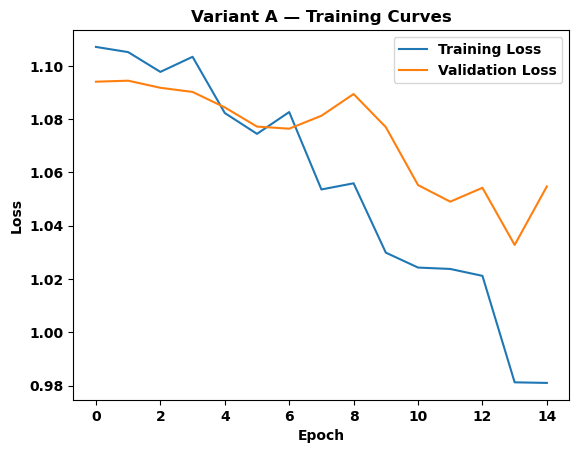

In [41]:
training_curves(train_losses_a, dev_losses_a, title="Variant A — Training Curves")

In [42]:
y_true_a, y_pred_a = predict(trained_model_a, test_loader_a)
acc_a, f1_a, pre_a = evaluate(y_pred_a, y_true_a, "Variant A — Test (plain)")


── Variant A — Test (plain) ──
Accuracy       : 0.3640
Macro-F1       : 0.3413
Macro-Precision: 0.3903

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.65      0.34      0.44       276
          no       0.41      0.40      0.40       169
       maybe       0.11      0.40      0.18        55

    accuracy                           0.36       500
   macro avg       0.39      0.38      0.34       500
weighted avg       0.51      0.36      0.40       500



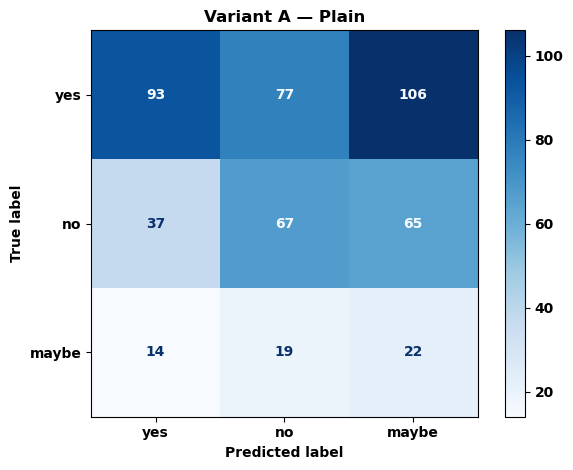

In [43]:
plot_confusion_matrix(y_true_a, y_pred_a, title="Variant A — Plain")

---
### Variant B — Question + context + MeSH (enriched representation)

In [44]:
set_all_seeds()

model_b = MLP(input_dim=768).to(DEVICE)
trained_model_b, train_losses_b, dev_losses_b = train_MLP(
    num_epochs, model_b, train_loader_b, dev_loader_b, learning_rate, class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.1043 Training Accuracy: 29.1111%
Epoch: 1/15 Validation Loss: 1.0949 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0949)
Epoch: 2/15 Training Loss: 1.1073 Training Accuracy: 34.0000%
Epoch: 2/15 Validation Loss: 1.0949 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0949)
Epoch: 3/15 Training Loss: 1.0960 Training Accuracy: 35.7778%
Epoch: 3/15 Validation Loss: 1.0912 Validation Accuracy: 38.0000%
Best model saved (validation_loss=1.0912)
Epoch: 4/15 Training Loss: 1.1013 Training Accuracy: 35.7778%
Epoch: 4/15 Validation Loss: 1.0892 Validation Accuracy: 36.0000%
Best model saved (validation_loss=1.0892)
Epoch: 5/15 Training Loss: 1.0935 Training Accuracy: 37.3333%
Epoch: 5/15 Validation Loss: 1.0862 Validation Accuracy: 44.0000%
Best model saved (validation_loss=1.0862)
Epoch: 6/15 Training Loss: 1.0821 Training Accuracy: 41.7778%
Epoch:

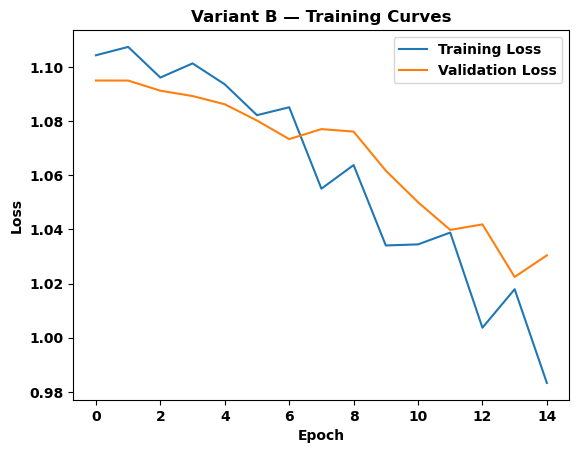

In [45]:
training_curves(train_losses_b, dev_losses_b, title="Variant B — Training Curves")

In [46]:
y_true_b, y_pred_b = predict(trained_model_b, test_loader_b)
acc_b, f1_b, pre_b = evaluate(y_pred_b, y_true_b, "Variant B — Test (+ MeSH)")


── Variant B — Test (+ MeSH) ──
Accuracy       : 0.3340
Macro-F1       : 0.3259
Macro-Precision: 0.4169

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.69      0.21      0.33       276
          no       0.43      0.47      0.45       169
       maybe       0.12      0.53      0.20        55

    accuracy                           0.33       500
   macro avg       0.42      0.40      0.33       500
weighted avg       0.54      0.33      0.35       500



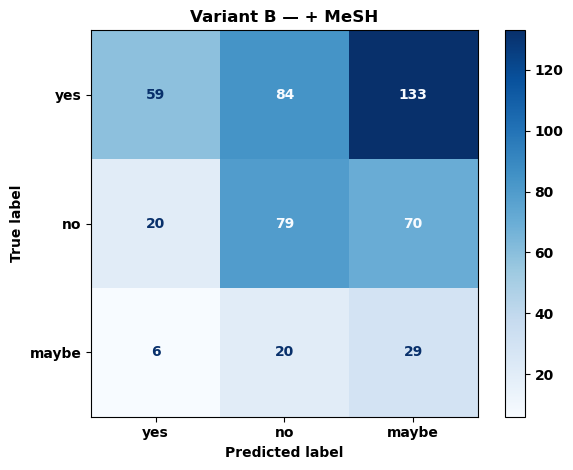

In [47]:
plot_confusion_matrix(y_true_b, y_pred_b, title="Variant B — + MeSH")

---
## Summary: Variant A vs. Variant B

In [48]:
print(f"{'Variant':<40} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>12}")
print("-" * 75)
for name, acc, f1, pre in [
    ("Variant A  — Plain (question + context)",  acc_a, f1_a, pre_a),
    ("Variant B  — Enriched (+ MeSH terms)",     acc_b, f1_b, pre_b),
]:
    print(f"{name:<40} {acc:>10.4f} {f1:>10.4f} {pre:>12.4f}")

Variant                                    Accuracy   Macro-F1   Macro-Prec
---------------------------------------------------------------------------
Variant A  — Plain (question + context)      0.3640     0.3413       0.3903
Variant B  — Enriched (+ MeSH terms)         0.3340     0.3259       0.4169


---
## Side-by-side Confusion Matrices

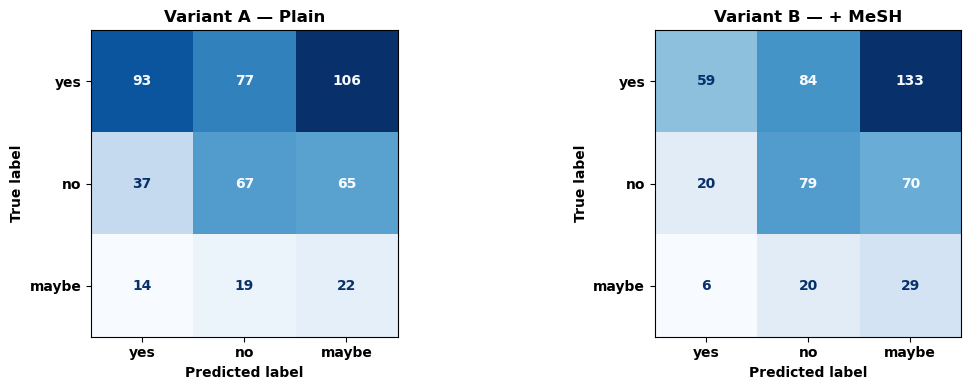

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_a, y_pred_a, "Variant A — Plain"),
    (axes[1], y_true_b, y_pred_b, "Variant B — + MeSH"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["yes", "no", "maybe"]
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()